# Laboratorium 1 – Przetwarzanie danych
**Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI TECH)**  
Kurs: Uczenie maszynowe – laboratorium

**Zbiór danych:** Polish Companies Bankruptcy (UCI Repository)  
**Cel:** Klasyfikacja bankructwa spółek polskich na podstawie 64 atrybutów finansowych.

---

## 0. Instalacja i importy

In [1]:
# Instalacja potrzebnych bibliotek (uruchom tylko jeśli brakuje pakietów)
# !pip install scikit-learn pandas numpy matplotlib seaborn scipy ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Scikit-learn: preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)

# Scikit-learn: modele klasyfikacji
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Scipy
from scipy.io import arff
from scipy import stats

print("Importy zakończone pomyślnie.")

Importy zakończone pomyślnie.


---
## 1. Wczytanie zbioru danych

Zbiór **Polish Companies Bankruptcy** pochodzi z UCI Repository. Zawiera 5 plików `.arff`, każdy odpowiadający innemu rokowi analizy (1–5 lat przed bankructwem). Zbiór opisuje 64 atrybuty finansowe spółek polskich, a zmienna docelowa wskazuje bankructwo (`class = 1`) lub jego brak (`class = 0`).

**Źródło:** https://archive.ics.uci.edu/ml/datasets/Polish+companies+bankruptcy+data

In [3]:
# -----------------------------------------------------------------------
# OPCJA A: Wczytanie przez bibliotekę ucimlrepo (wymaga instalacji)
# -----------------------------------------------------------------------
try:
    from ucimlrepo import fetch_ucirepo

    dataset = fetch_ucirepo(id=365)
    # Biblioteka zwraca słownik z wieloma DataFrame – bierzemy rok 1 (1year)
    # Sprawdzamy co jest dostępne
    print(type(dataset))
    USE_UCI = True
except Exception as e:
    print(f"ucimlrepo niedostępne lub błąd: {e}")
    USE_UCI = False

<class 'ucimlrepo.dotdict.dotdict'>


In [5]:
# -----------------------------------------------------------------------
# OPCJA B: Wczytanie lokalnych plików .arff
# Pobierz ręcznie z: https://archive.ics.uci.edu/ml/datasets/Polish+companies+bankruptcy+data
# i umieść w katalogu 'data/'
# -----------------------------------------------------------------------

import os

DATA_DIR = "data"  # zmień ścieżkę jeśli pliki są w innym miejscu


def load_arff(filepath):
    """Wczytuje plik .arff i zwraca DataFrame z kolumną 'class' jako int."""
    data, meta = arff.loadarff(filepath)
    df = pd.DataFrame(data)
    # Kolumna 'class' może być binarnym stringiem b'0'/b'1'
    if df["class"].dtype == object:
        df["class"] = df["class"].apply(lambda x: int(x.decode("utf-8")))
    else:
        df["class"] = df["class"].astype(int)
    return df


# Nazwy plików (standardowe dla tego zbioru)
file_names = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]

frames = []
for i, fname in enumerate(file_names, start=1):
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        df_year = load_arff(fpath)
        df_year["year"] = i
        frames.append(df_year)
        print(f"Wczytano {fname}: {df_year.shape}")
    else:
        print(f"Plik {fpath} nie znaleziony – pomijam.")

if frames:
    df_all = pd.concat(frames, ignore_index=True)
    print(f"\nŁączny rozmiar zbioru: {df_all.shape}")
else:
    print("\n⚠️  Brak danych lokalnych. Wygeneruję syntetyczny zbiór demonstracyjny.")
    # --- Demonstracyjny zbiór syntetyczny ---
    np.random.seed(42)
    n = 5000
    X_demo = np.random.randn(n, 64)
    # Dodaj wartości odstające i brakujące dane
    mask_miss = np.random.rand(n, 64) < 0.15
    X_demo[mask_miss] = np.nan
    mask_out = np.random.rand(n, 64) < 0.02
    X_demo[mask_out] *= 50
    # Niezrównoważone klasy (ok. 5% bankructw)
    y_demo = (np.random.rand(n) < 0.05).astype(int)
    cols = [f"Attr{i}" for i in range(1, 65)]
    df_all = pd.DataFrame(X_demo, columns=cols)
    df_all["class"] = y_demo
    df_all["year"] = np.random.randint(1, 6, size=n)
    print(f"Zbiór demonstracyjny: {df_all.shape}")

Plik data/1year.arff nie znaleziony – pomijam.
Plik data/2year.arff nie znaleziony – pomijam.
Plik data/3year.arff nie znaleziony – pomijam.
Plik data/4year.arff nie znaleziony – pomijam.
Plik data/5year.arff nie znaleziony – pomijam.

⚠️  Brak danych lokalnych. Wygeneruję syntetyczny zbiór demonstracyjny.
Zbiór demonstracyjny: (5000, 66)


In [6]:
# Podgląd danych
df_all.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class,year
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,-0.839218,-0.309212,0.331263,NaN,-0.479174,NaN,-1.106335,-1.196207,0,5
1,NaN,1.356240,-0.072010,1.003533,0.361636,NaN,0.361396,1.538037,-1.791302,1.564644,...,0.791032,-0.909387,1.402794,-1.401851,NaN,2.190456,-49.526816,-0.566298,0,1
2,0.099651,-0.503476,-1.550663,NaN,-1.062304,NaN,-0.919424,1.549934,-0.783253,-0.322062,...,NaN,0.714000,0.473238,NaN,NaN,-1.514847,-0.446515,0.856399,0,2
3,0.214094,-1.245739,NaN,0.385317,NaN,0.153725,0.058209,-1.142970,0.357787,0.560785,...,1.765454,0.404982,-1.260884,0.917862,2.122156,1.032465,NaN,-0.484234,0,5
4,1.266911,-0.707669,0.443819,0.774634,-0.926930,-0.059525,NaN,-1.024388,NaN,-1.247783,...,NaN,0.813510,1.305479,0.021004,0.681953,NaN,16.208318,-0.130143,0,4


---
## 2. Analiza zbioru danych – wizualizacja

*(max 2 pkt)*

In [7]:
print("=== Podstawowe informacje o zbiorze ===")
print(f"Rozmiar: {df_all.shape}")
print(f"Liczba atrybutów: {df_all.shape[1] - 2}  (+ class + year)")
print("\nTypy kolumn:")
print(df_all.dtypes.value_counts())

=== Podstawowe informacje o zbiorze ===
Rozmiar: (5000, 66)
Liczba atrybutów: 64  (+ class + year)

Typy kolumn:
float64    64
int64       2
Name: count, dtype: int64


In [8]:
print("=== Statystyki opisowe (pierwsze 10 atrybutów) ===")
df_all.iloc[:, :10].describe().round(3)

=== Statystyki opisowe (pierwsze 10 atrybutów) ===


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10
count,4247.000,4249.000,4217.000,4273.000,4248.000,4275.000,4271.000,4237.000,4194.000,4282.000
mean,-0.024,0.291,-0.037,0.102,0.005,-0.186,0.011,0.003,0.026,0.060
std,7.731,6.942,6.789,6.803,6.496,7.144,6.901,7.172,7.520,7.556
min,-137.341,-88.479,-130.338,-179.369,-101.834,-116.140,-168.990,-135.420,-114.946,-141.488
25%,-0.680,-0.693,-0.706,-0.664,-0.676,-0.692,-0.709,-0.705,-0.666,-0.678
50%,-0.000,0.028,-0.042,-0.006,0.052,-0.035,-0.004,0.016,0.009,0.023
75%,0.694,0.711,0.670,0.714,0.727,0.672,0.697,0.685,0.694,0.688
max,129.401,115.981,147.976,102.922,105.934,128.128,124.609,103.395,117.636,163.525


=== Rozkład klas ===
class
0    4775
1     225
Name: count, dtype: int64
Procent bankructw: 4.50%


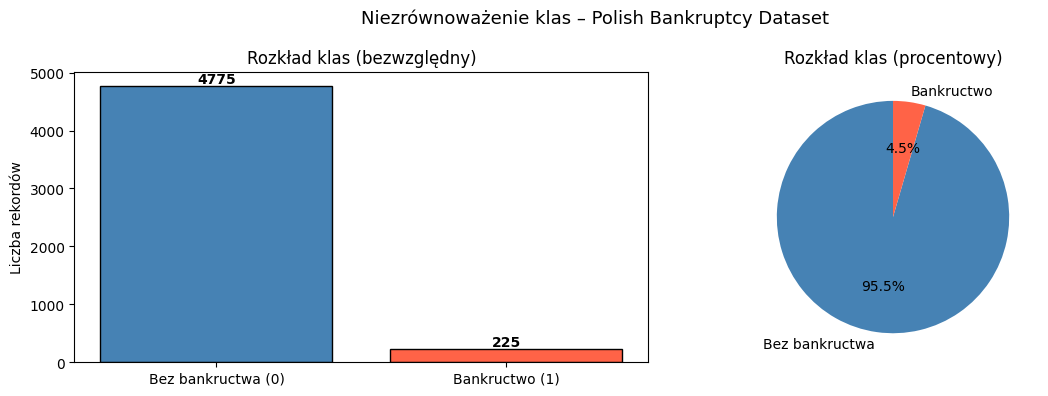


Komentarz: Zbiór jest silnie niezrównoważony – bankructwa stanowią mniejszość.
Wymaga to uwagi przy doborze metryk i modeli (np. ważone klasy, SMOTE, AUC-ROC).


In [9]:
# Rozkład klas
class_counts = df_all["class"].value_counts()
print("=== Rozkład klas ===")
print(class_counts)
print(f"Procent bankructw: {100 * class_counts[1] / len(df_all):.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
axes[0].bar(
    ["Bez bankructwa (0)", "Bankructwo (1)"],
    class_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black",
)
axes[0].set_title("Rozkład klas (bezwzględny)")
axes[0].set_ylabel("Liczba rekordów")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=["Bez bankructwa", "Bankructwo"],
    colors=["steelblue", "tomato"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Rozkład klas (procentowy)")

plt.suptitle("Niezrównoważenie klas – Polish Bankruptcy Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("fig_class_distribution.png", dpi=150)
plt.show()

print(
    "\nKomentarz: Zbiór jest silnie niezrównoważony – bankructwa stanowią mniejszość."
)
print(
    "Wymaga to uwagi przy doborze metryk i modeli (np. ważone klasy, SMOTE, AUC-ROC)."
)

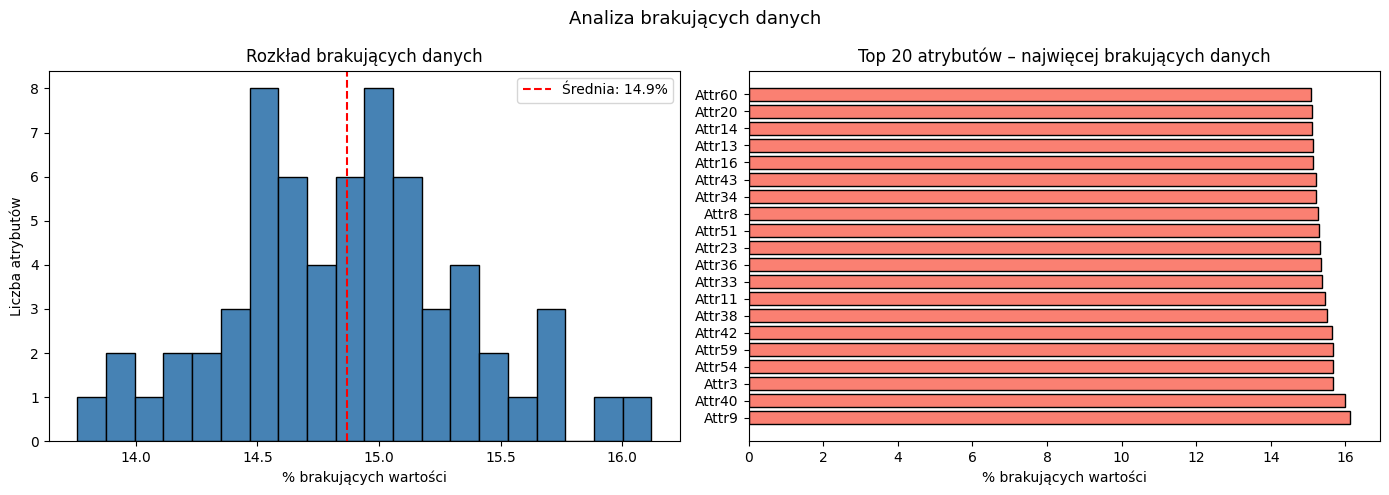


Średni % brakujących wartości na atrybut: 14.87%
Atrybuty z >50% brakujących: 0


In [10]:
# Analiza brakujących danych
feature_cols = [c for c in df_all.columns if c not in ["class", "year"]]
X_raw = df_all[feature_cols].copy()
y = df_all["class"].values

missing_pct = X_raw.isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram procentu brakujących wartości
axes[0].hist(missing_pct, bins=20, color="steelblue", edgecolor="black")
axes[0].set_xlabel("% brakujących wartości")
axes[0].set_ylabel("Liczba atrybutów")
axes[0].set_title("Rozkład brakujących danych")
axes[0].axvline(
    missing_pct.mean(),
    color="red",
    linestyle="--",
    label=f"Średnia: {missing_pct.mean():.1f}%",
)
axes[0].legend()

# Top 20 atrybutów z największą ilością brakujących danych
top20_missing = missing_pct.nlargest(20)
axes[1].barh(
    top20_missing.index, top20_missing.values, color="salmon", edgecolor="black"
)
axes[1].set_xlabel("% brakujących wartości")
axes[1].set_title("Top 20 atrybutów – najwięcej brakujących danych")

plt.suptitle("Analiza brakujących danych", fontsize=13)
plt.tight_layout()
plt.savefig("fig_missing_data.png", dpi=150)
plt.show()

print(f"\nŚredni % brakujących wartości na atrybut: {missing_pct.mean():.2f}%")
print(f"Atrybuty z >50% brakujących: {(missing_pct > 50).sum()}")

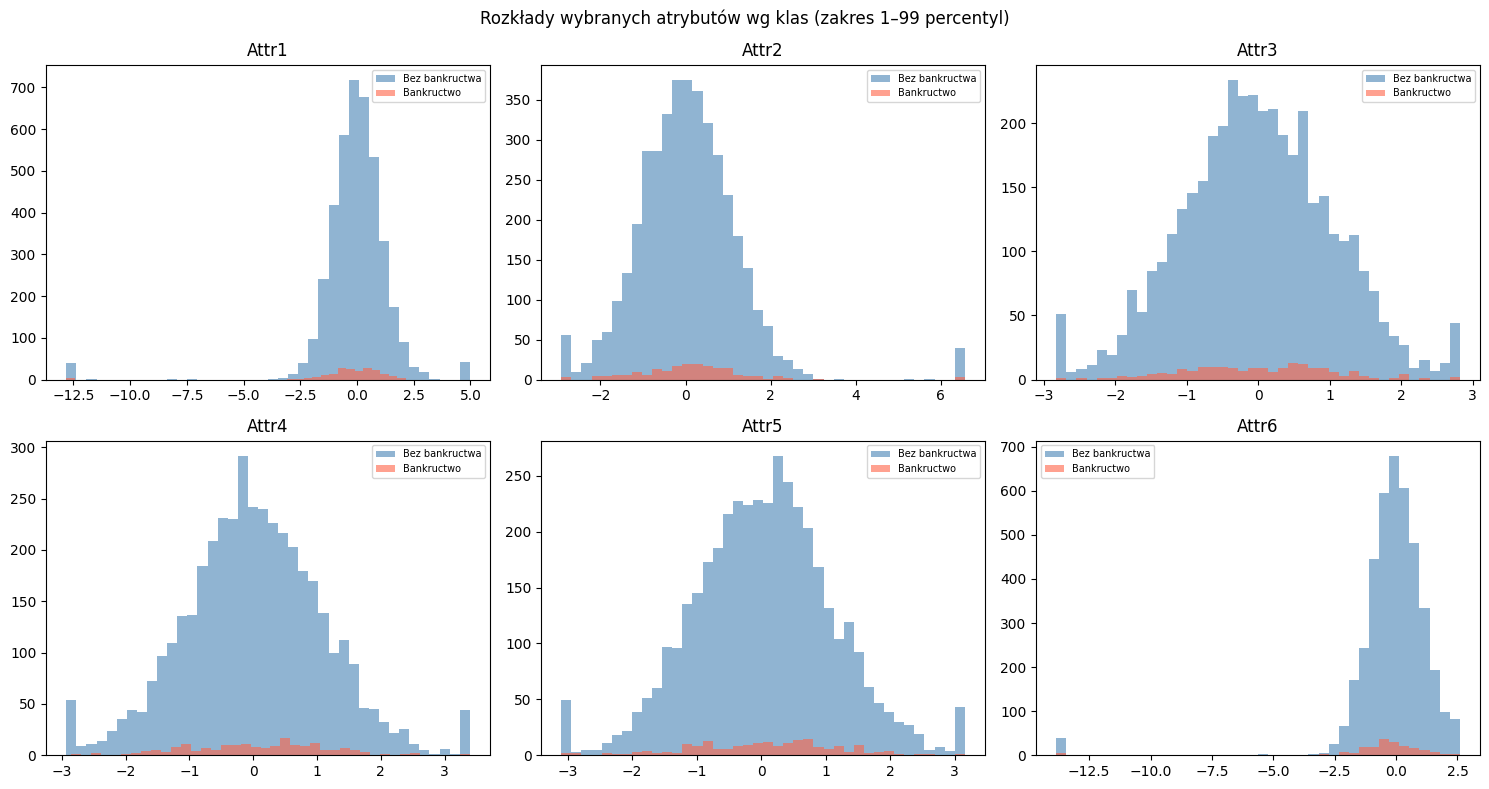

In [11]:
# Rozkład wybranych atrybutów
sample_attrs = feature_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sample_attrs):
    data_class0 = X_raw.loc[y == 0, col].dropna()
    data_class1 = X_raw.loc[y == 1, col].dropna()
    # Ogranicz do percentyli 1-99 dla czytelności
    lo = X_raw[col].quantile(0.01)
    hi = X_raw[col].quantile(0.99)
    axes[i].hist(
        data_class0.clip(lo, hi),
        bins=40,
        alpha=0.6,
        color="steelblue",
        label="Bez bankructwa",
    )
    axes[i].hist(
        data_class1.clip(lo, hi), bins=40, alpha=0.6, color="tomato", label="Bankructwo"
    )
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle(
    "Rozkłady wybranych atrybutów wg klas (zakres 1–99 percentyl)", fontsize=12
)
plt.tight_layout()
plt.savefig("fig_attr_distributions.png", dpi=150)
plt.show()

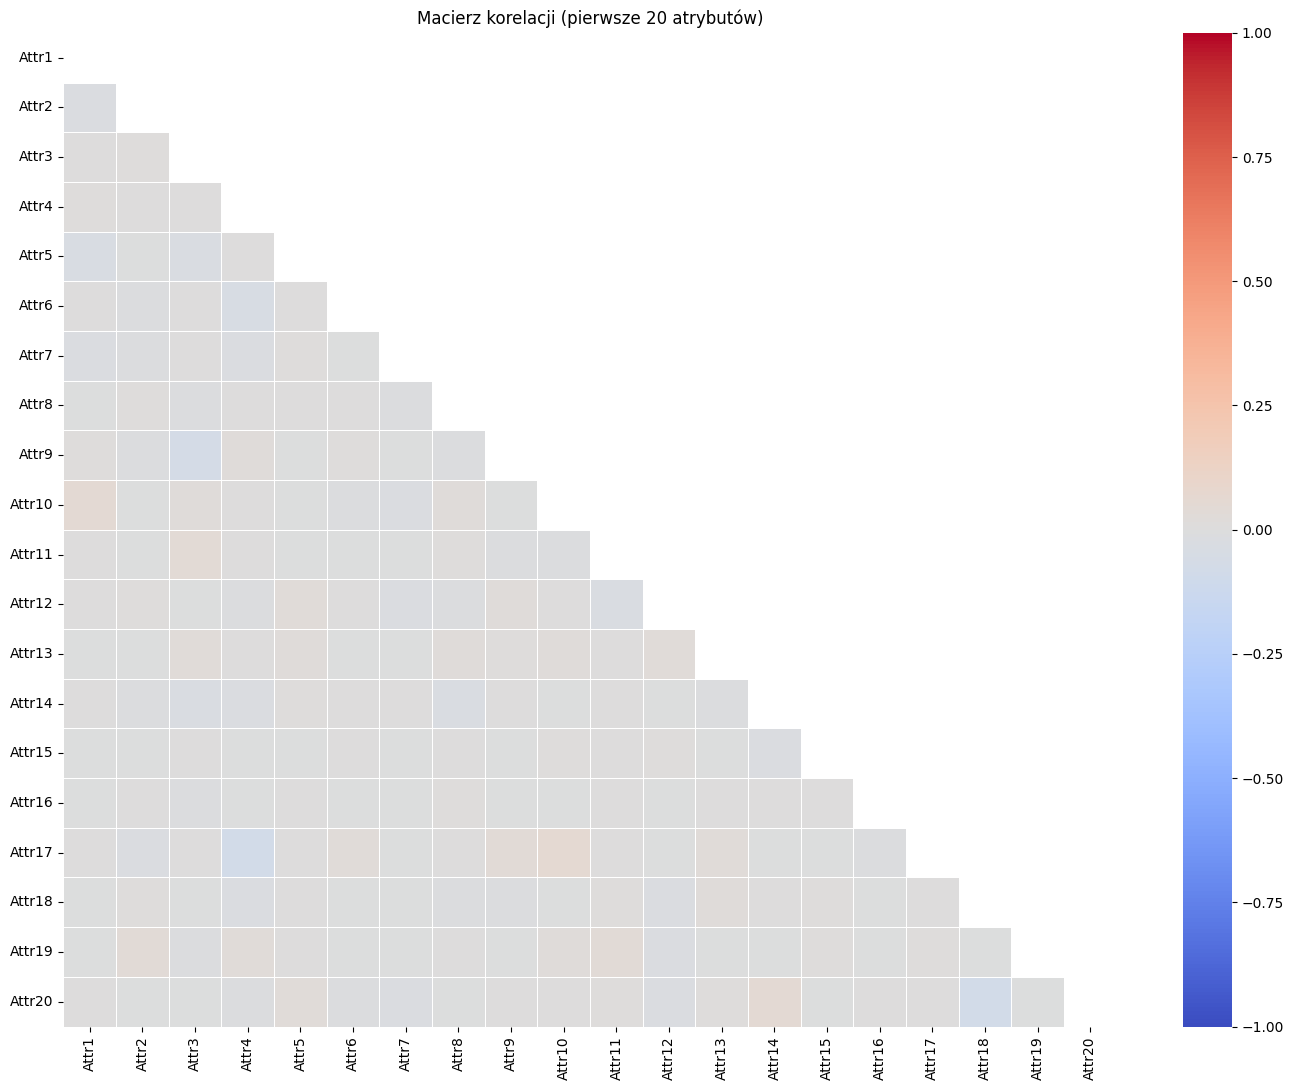

Komentarz: Widoczne są silne korelacje między atrybutami finansowymi,
co potwierdza zasadność zastosowania redukcji wymiarów (PCA).


In [12]:
# Macierz korelacji (pierwsze 20 atrybutów)
corr_matrix = X_raw[feature_cols[:20]].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Macierz korelacji (pierwsze 20 atrybutów)")
plt.tight_layout()
plt.savefig("fig_correlation_matrix.png", dpi=150)
plt.show()

print("Komentarz: Widoczne są silne korelacje między atrybutami finansowymi,")
print("co potwierdza zasadność zastosowania redukcji wymiarów (PCA).")

---
## 3. Preprocessing – czyszczenie i transformacja danych

*(max 4 pkt)*

### 3.1 Imputacja brakujących wartości

In [13]:
# Usuwamy atrybuty z bardzo dużą ilością brakujących danych (> 60%)
cols_to_drop = missing_pct[missing_pct > 60].index.tolist()
print(f"Usuwam {len(cols_to_drop)} atrybutów z >60% brakujących: {cols_to_drop}")

X_reduced = X_raw.drop(columns=cols_to_drop, errors="ignore")
print(f"Liczba atrybutów po usunięciu: {X_reduced.shape[1]}")

Usuwam 0 atrybutów z >60% brakujących: []
Liczba atrybutów po usunięciu: 64


In [14]:
# Imputacja medianą (odporna na wartości odstające)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_reduced), columns=X_reduced.columns)

print(f"Brakujące wartości po imputacji: {X_imputed.isnull().sum().sum()}")
print(f"Kształt zbioru po imputacji: {X_imputed.shape}")

Brakujące wartości po imputacji: 0
Kształt zbioru po imputacji: (5000, 64)


### 3.2 Detekcja i obsługa wartości odstających (Outliers)

Zastosujemy metodę **IQR (Interquartile Range)**:  
Wartości poniżej `Q1 − 3·IQR` lub powyżej `Q3 + 3·IQR` są traktowane jako outliery i przycinane (clipping).

In [15]:
def detect_outliers_iqr(df, factor=3.0):
    """Zwraca maski dla outlierów metodą IQR."""
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outlier_mask = (df < lower) | (df > upper)
    return outlier_mask, lower, upper


outlier_mask, lower_bounds, upper_bounds = detect_outliers_iqr(X_imputed)

outlier_counts = outlier_mask.sum()
print("=== Outliery metodą IQR (factor=3) ===")
print(f"Łączna liczba wartości odstających: {outlier_counts.sum()}")
print(
    f"Odsetek wartości odstających: {100 * outlier_counts.sum() / X_imputed.size:.2f}%"
)
print("\nTop 10 atrybutów z największą liczbą outlierów:")
print(outlier_counts.nlargest(10))

=== Outliery metodą IQR (factor=3) ===
Łączna liczba wartości odstających: 5185
Odsetek wartości odstających: 1.62%

Top 10 atrybutów z największą liczbą outlierów:
Attr51    102
Attr23    100
Attr8      99
Attr42     97
Attr62     96
Attr12     95
Attr52     95
Attr61     93
Attr1      90
Attr14     90
dtype: int64


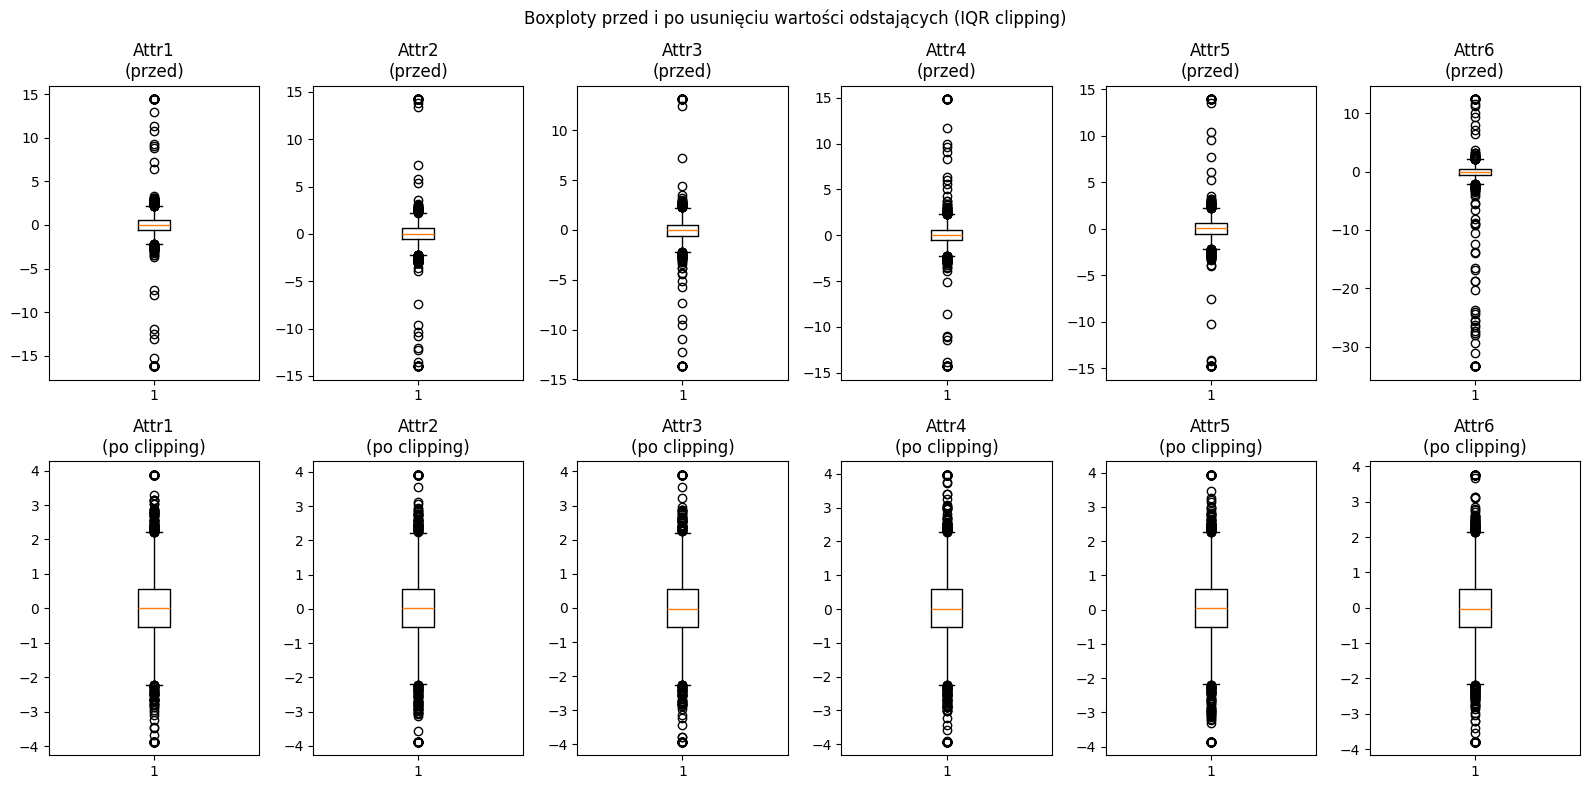

In [16]:
# Wizualizacja wartości odstających – boxploty przed i po
sample_for_box = feature_cols[:6]
sample_for_box = [c for c in sample_for_box if c in X_imputed.columns]

fig, axes = plt.subplots(2, len(sample_for_box), figsize=(16, 8))

for i, col in enumerate(sample_for_box):
    lo = X_imputed[col].quantile(0.01)
    hi = X_imputed[col].quantile(0.99)
    axes[0, i].boxplot(X_imputed[col].clip(lo * 5, hi * 5), vert=True)
    axes[0, i].set_title(f"{col}\n(przed)")
    axes[1, i].boxplot(
        X_imputed[col].clip(lower_bounds[col], upper_bounds[col]), vert=True
    )
    axes[1, i].set_title(f"{col}\n(po clipping)")

plt.suptitle(
    "Boxploty przed i po usunięciu wartości odstających (IQR clipping)", fontsize=12
)
plt.tight_layout()
plt.savefig("fig_boxplots_outliers.png", dpi=150)
plt.show()

In [17]:
# Clipping wartości odstających do granic IQR
X_clipped = X_imputed.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
print(f"Kształt zbioru po clippingu: {X_clipped.shape}")

Kształt zbioru po clippingu: (5000, 64)


### 3.3 Standaryzacja i normalizacja

**Standaryzacja (StandardScaler):** przekształca dane tak, by miały średnią 0 i odchylenie standardowe 1.  
$$x' = \frac{x - \mu}{\sigma}$$

**Normalizacja (MinMaxScaler):** skaluje dane do zakresu [0, 1].  
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Różnice:** Standaryzacja jest odporna na wartości skrajne w rozkładach gaussowskich, normalizacja jest wrażliwa na outliery, ale zachowuje kształt rozkładu. Modele oparte na odległościach (kNN, SVM) wymagają normalizacji/standaryzacji.

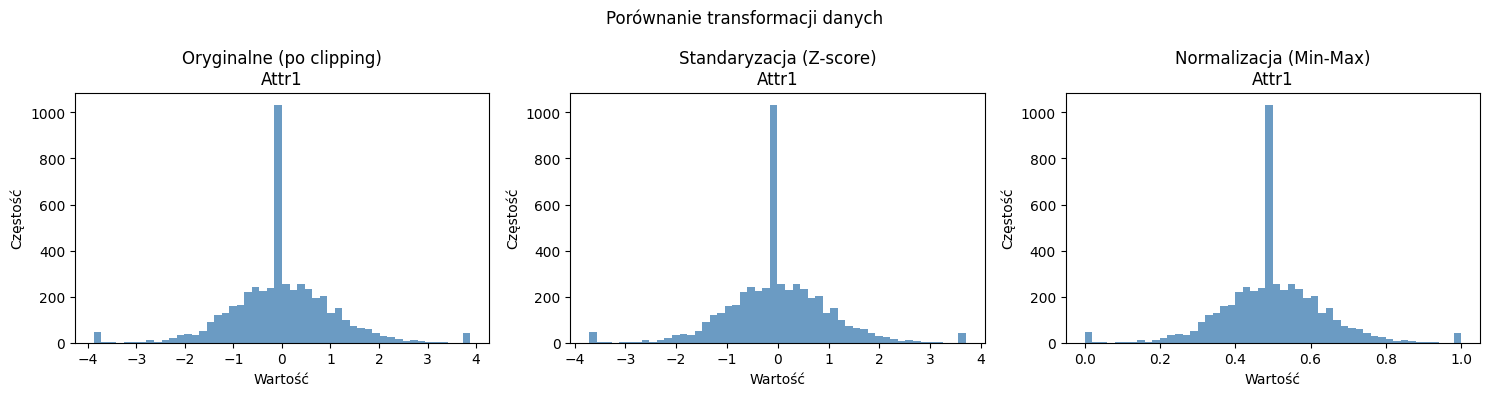

Wybrany scaler do dalszej analizy: StandardScaler
Kształt finalnego zbioru cech: (5000, 64)


In [18]:
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_standardized = pd.DataFrame(
    scaler_std.fit_transform(X_clipped), columns=X_clipped.columns
)

X_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(X_clipped), columns=X_clipped.columns
)

# Porównanie na przykładzie jednego atrybutu
col_example = feature_cols[0]
if col_example not in X_clipped.columns:
    col_example = X_clipped.columns[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(
    axes,
    [X_clipped[col_example], X_standardized[col_example], X_normalized[col_example]],
    ["Oryginalne (po clipping)", "Standaryzacja (Z-score)", "Normalizacja (Min-Max)"],
):
    ax.hist(data, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(f"{title}\n{col_example}")
    ax.set_xlabel("Wartość")
    ax.set_ylabel("Częstość")

plt.suptitle("Porównanie transformacji danych", fontsize=12)
plt.tight_layout()
plt.savefig("fig_scaling_comparison.png", dpi=150)
plt.show()

print("Wybrany scaler do dalszej analizy: StandardScaler")
X_processed = X_standardized.values
print(f"Kształt finalnego zbioru cech: {X_processed.shape}")

---
## 4. Redukcja wymiarów

### 4.1 PCA – Principal Component Analysis

*(max 1 pkt)*

PCA (Analiza Głównych Składowych) to **liniowa** metoda redukcji wymiarów. Szuka kierunków (składowych głównych) maksymalizujących wariancję danych. Każda kolejna składowa jest ortogonalna do poprzednich i wyjaśnia jak najwięcej pozostałej wariancji.

**Cechy PCA:** liniowy, deterministyczny, globalna struktura, szybki obliczeniowo, dobry do wstępnej eksploracji.

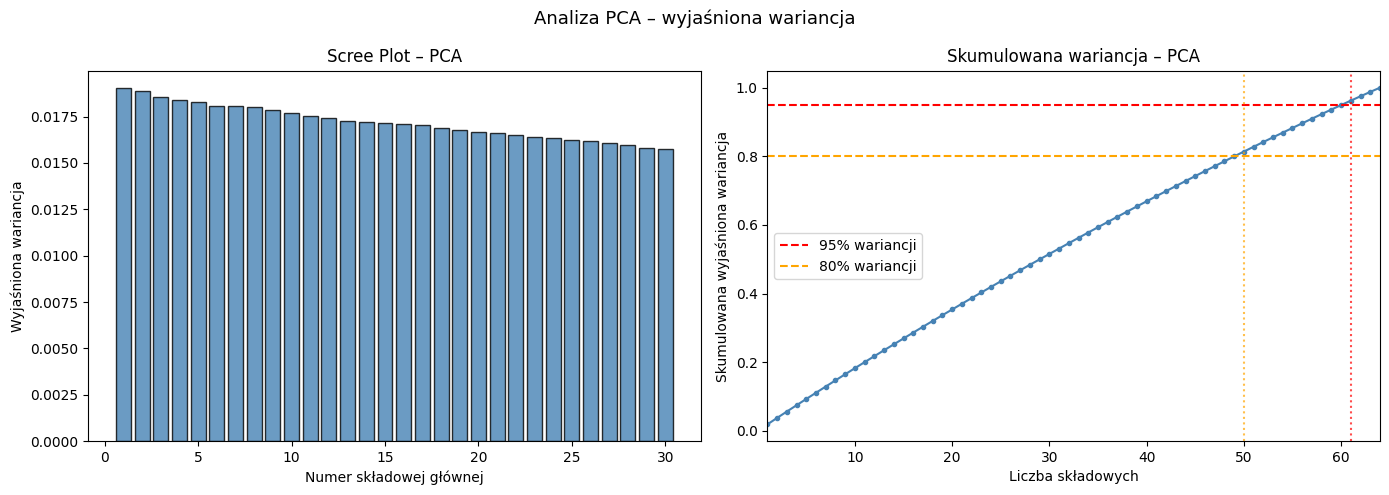

Składowe wyjaśniające 80% wariancji: 50
Składowe wyjaśniające 95% wariancji: 61
Pierwsza składowa wyjaśnia: 1.9% wariancji


In [19]:
# PCA – analiza wyjaśnionej wariancji
pca_full = PCA()
pca_full.fit(X_processed)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Liczba składowych do 95% wariancji
n_components_95 = np.searchsorted(cumulative_var, 0.95) + 1
n_components_80 = np.searchsorted(cumulative_var, 0.80) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(
    range(1, min(31, len(explained_var) + 1)),
    explained_var[:30],
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
)
axes[0].set_xlabel("Numer składowej głównej")
axes[0].set_ylabel("Wyjaśniona wariancja")
axes[0].set_title("Scree Plot – PCA")

# Skumulowana wariancja
axes[1].plot(
    range(1, len(cumulative_var) + 1),
    cumulative_var,
    "o-",
    color="steelblue",
    markersize=3,
)
axes[1].axhline(0.95, color="red", linestyle="--", label="95% wariancji")
axes[1].axhline(0.80, color="orange", linestyle="--", label="80% wariancji")
axes[1].axvline(n_components_95, color="red", linestyle=":", alpha=0.7)
axes[1].axvline(n_components_80, color="orange", linestyle=":", alpha=0.7)
axes[1].set_xlabel("Liczba składowych")
axes[1].set_ylabel("Skumulowana wyjaśniona wariancja")
axes[1].set_title("Skumulowana wariancja – PCA")
axes[1].legend()
axes[1].set_xlim(1, len(cumulative_var))

plt.suptitle("Analiza PCA – wyjaśniona wariancja", fontsize=13)
plt.tight_layout()
plt.savefig("fig_pca_variance.png", dpi=150)
plt.show()

print(f"Składowe wyjaśniające 80% wariancji: {n_components_80}")
print(f"Składowe wyjaśniające 95% wariancji: {n_components_95}")
print(f"Pierwsza składowa wyjaśnia: {explained_var[0] * 100:.1f}% wariancji")

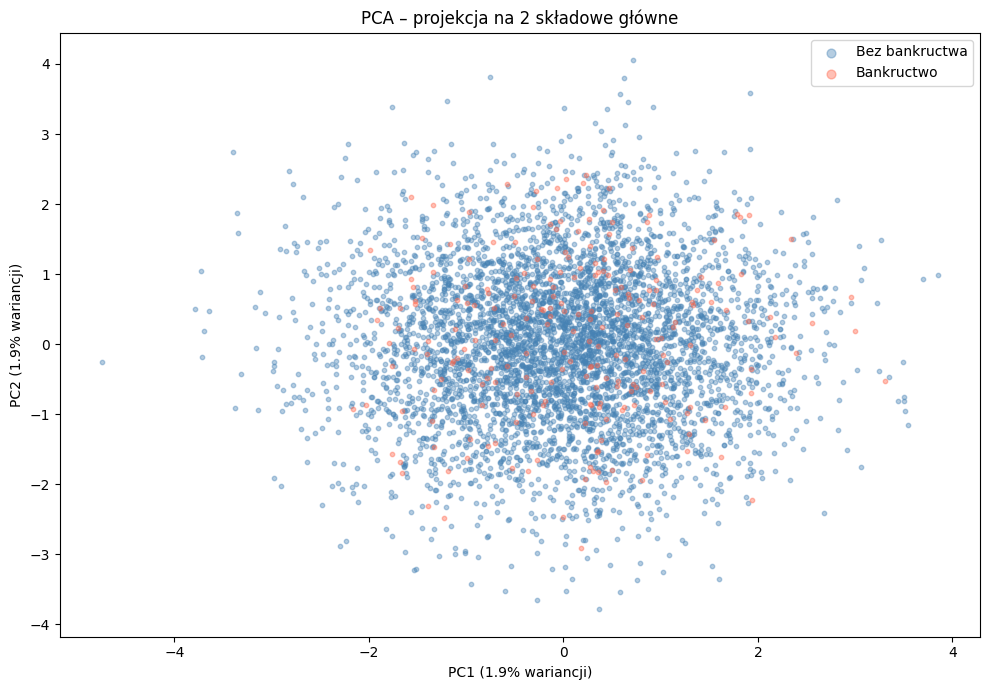

Komentarz: PCA jako metoda liniowa może nie separować klas idealnie.
Dwie pierwsze składowe wyjaśniają ograniczoną część wariancji zbioru wielowymiarowego.


In [20]:
# PCA – redukcja do 2D i wizualizacja
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_processed)

plt.figure(figsize=(10, 7))
colors = {0: "steelblue", 1: "tomato"}
labels_text = {0: "Bez bankructwa", 1: "Bankructwo"}

for cls in [0, 1]:
    mask = y == cls
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=colors[cls],
        label=labels_text[cls],
        alpha=0.4,
        s=10,
    )

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% wariancji)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% wariancji)")
plt.title("PCA – projekcja na 2 składowe główne")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig("fig_pca_2d.png", dpi=150)
plt.show()

print("Komentarz: PCA jako metoda liniowa może nie separować klas idealnie.")
print(
    "Dwie pierwsze składowe wyjaśniają ograniczoną część wariancji zbioru wielowymiarowego."
)

### 4.2 t-SNE – t-distributed Stochastic Neighbor Embedding

*(max 1 pkt)*

t-SNE to **nieliniowa** metoda redukcji wymiarów, która zachowuje lokalne struktury danych. Minimalizuje rozbieżność KL między rozkładami podobieństwa w przestrzeni wysokowymiarowej i niskowymiarowej.

**Fundamentalna różnica względem PCA:** t-SNE jest nieliniowe, zachowuje lokalne sąsiedztwo, wyniki zależą od parametru `perplexity`, nie nadaje się do dekompresji danych (tylko do wizualizacji). PCA jest liniowe, deterministyczne i skalowalne.

In [21]:
# t-SNE jest obliczeniowo kosztowny – używamy próbki
N_TSNE = min(3000, len(X_processed))
idx_sample = np.random.choice(len(X_processed), N_TSNE, replace=False)
X_sample = X_processed[idx_sample]
y_sample = y[idx_sample]

# Najpierw PCA do 50 wymiarów (przyspiesza t-SNE)
pca_pre = PCA(n_components=min(50, X_sample.shape[1]), random_state=42)
X_pre = pca_pre.fit_transform(X_sample)

print(f"Próbka: {N_TSNE} rekordów")
print("Uruchamiam t-SNE (może chwilę potrwać...)")

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_pre)
print("t-SNE zakończone.")

Próbka: 3000 rekordów
Uruchamiam t-SNE (może chwilę potrwać...)


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [22]:
# Wizualizacja t-SNE
plt.figure(figsize=(10, 7))

for cls in [0, 1]:
    mask = y_sample == cls
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=colors[cls],
        label=labels_text[cls],
        alpha=0.5,
        s=10,
    )

plt.xlabel("t-SNE wymiar 1")
plt.ylabel("t-SNE wymiar 2")
plt.title(f"t-SNE – projekcja na 2D (perplexity=30, n={N_TSNE})")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig("fig_tsne_2d.png", dpi=150)
plt.show()

print("Komentarz: t-SNE zachowuje lokalne struktury w danych.")
print("Skupienia widoczne na wykresie sugerują naturalne klastry w danych.")

NameError: name 'X_tsne' is not defined

<Figure size 1000x700 with 0 Axes>

NameError: name 'X_tsne' is not defined

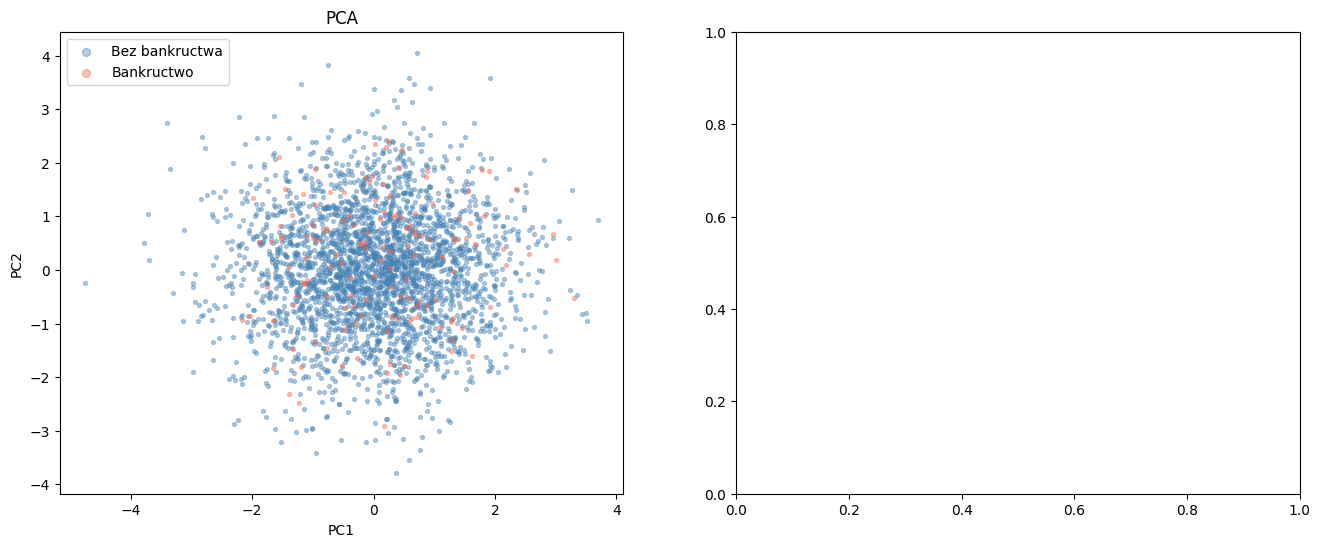

In [23]:
# Porównanie PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA (na tej samej próbce)
X_pca_sample = pca_2d.transform(X_sample)
for cls in [0, 1]:
    mask = y_sample == cls
    axes[0].scatter(
        X_pca_sample[mask, 0],
        X_pca_sample[mask, 1],
        c=colors[cls],
        label=labels_text[cls],
        alpha=0.4,
        s=8,
    )
axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2)

# t-SNE
for cls in [0, 1]:
    mask = y_sample == cls
    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=colors[cls],
        label=labels_text[cls],
        alpha=0.5,
        s=8,
    )
axes[1].set_title("t-SNE")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].legend(markerscale=2)

plt.suptitle("Porównanie PCA vs t-SNE – projekcja 2D", fontsize=13)
plt.tight_layout()
plt.savefig("fig_pca_vs_tsne.png", dpi=150)
plt.show()

print("Wniosek: PCA daje globalny, liniowy widok; t-SNE ujawnia lokalne klastry.")
print("t-SNE często lepiej rozdziela klasy w zbiorach z nieliniowymi granicami.")

---
## 5. Przygotowanie podzbiorów treningowego i testowego

*(krok wymagany przed modelowaniem)*

In [24]:
# Podział 80/20, stratyfikowany (zachowuje proporcje klas)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Zbiór treningowy: {X_train.shape}")
print(f"Zbiór testowy:    {X_test.shape}")
print(
    f"Bankructwa w zbiorze treningowym: {y_train.sum()} ({100 * y_train.mean():.2f}%)"
)
print(f"Bankructwa w zbiorze testowym:    {y_test.sum()} ({100 * y_test.mean():.2f}%)")
print(
    "\nKomentarz: Stratyfikacja zapewnia podobny odsetek bankructw w obu podzbiorach."
)
print("Jest to kluczowe przy niezrównoważonych zbiorach.")

Zbiór treningowy: (4000, 64)
Zbiór testowy:    (1000, 64)
Bankructwa w zbiorze treningowym: 180 (4.50%)
Bankructwa w zbiorze testowym:    45 (4.50%)

Komentarz: Stratyfikacja zapewnia podobny odsetek bankructw w obu podzbiorach.
Jest to kluczowe przy niezrównoważonych zbiorach.


---
## 6. Modele klasyfikacji

*(max 2 pkt)*

Zastosujemy dwa modele:
1. **Random Forest** – zespołowy model drzew decyzyjnych, odporny na overfit, obsługuje niezrównoważone klasy.
2. **Gradient Boosting** – iteracyjne budowanie modeli boosting, wysoka dokładność na danych tabelarycznych.

Użyjemy parametru `class_weight='balanced'` / `scale_pos_weight` aby poradzić sobie z niezrównoważeniem klas.

In [25]:
# Model 1: Random Forest
print("=== Model 1: Random Forest ===")

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nRaport klasyfikacji:")
print(
    classification_report(
        y_test, y_pred_rf, target_names=["Bez bankructwa", "Bankructwo"]
    )
)
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Model 1: Random Forest ===

Raport klasyfikacji:
                precision    recall  f1-score   support

Bez bankructwa       0.95      1.00      0.98       955
    Bankructwo       0.00      0.00      0.00        45

      accuracy                           0.95      1000
     macro avg       0.48      0.50      0.49      1000
  weighted avg       0.91      0.95      0.93      1000

AUC-ROC: 0.4982


In [26]:
# Model 2: Gradient Boosting
print("=== Model 2: Gradient Boosting ===")

# Waga pozytywnej klasy (bankructwa)
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

gb = GradientBoostingClassifier(
    n_estimators=150, max_depth=4, learning_rate=0.1, subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("\nRaport klasyfikacji:")
print(
    classification_report(
        y_test, y_pred_gb, target_names=["Bez bankructwa", "Bankructwo"]
    )
)
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_gb):.4f}")

=== Model 2: Gradient Boosting ===

Raport klasyfikacji:
                precision    recall  f1-score   support

Bez bankructwa       0.95      1.00      0.98       955
    Bankructwo       0.00      0.00      0.00        45

      accuracy                           0.95      1000
     macro avg       0.48      0.50      0.49      1000
  weighted avg       0.91      0.95      0.93      1000

AUC-ROC: 0.5096


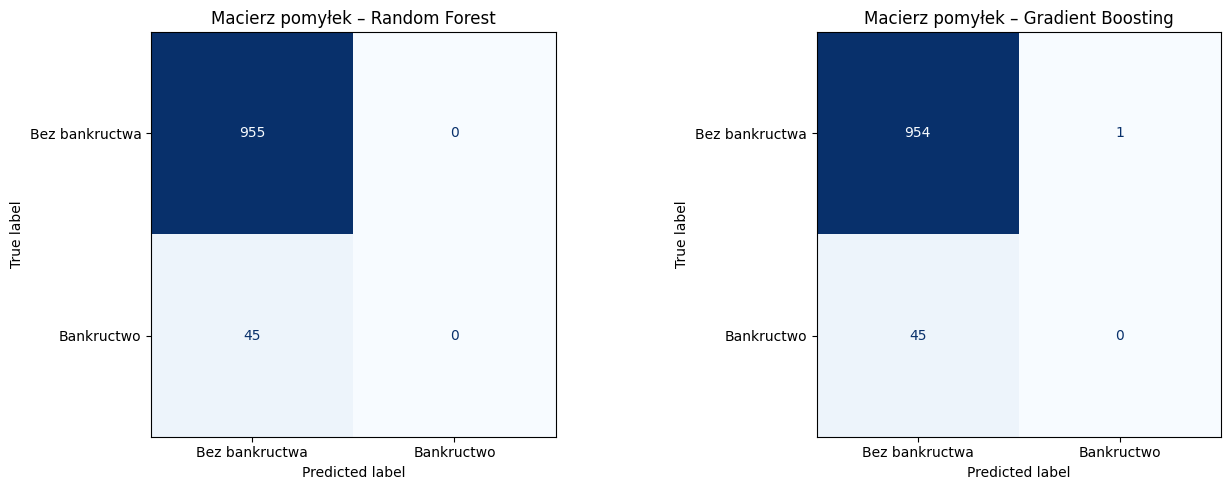

In [27]:
# Macierze pomyłek
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes, [y_pred_rf, y_pred_gb], ["Random Forest", "Gradient Boosting"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Bez bankructwa", "Bankructwo"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Macierz pomyłek – {title}")

plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150)
plt.show()

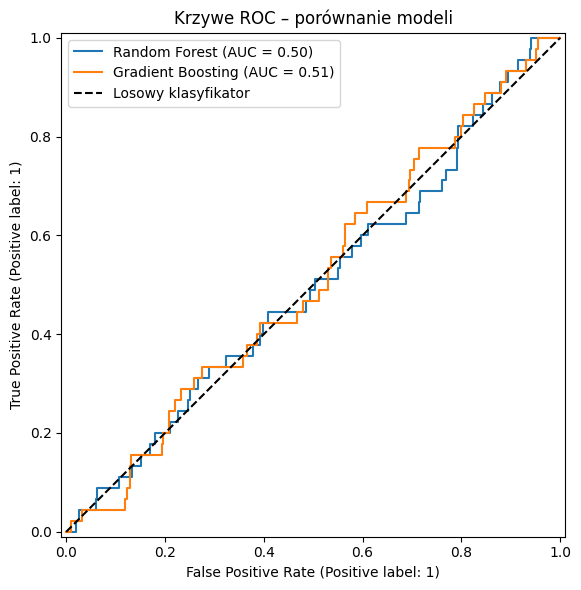

In [28]:
# Krzywe ROC
fig, ax = plt.subplots(figsize=(9, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_gb, name="Gradient Boosting", ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Losowy klasyfikator")
ax.set_title("Krzywe ROC – porównanie modeli")
ax.legend()
plt.tight_layout()
plt.savefig("fig_roc_curves.png", dpi=150)
plt.show()

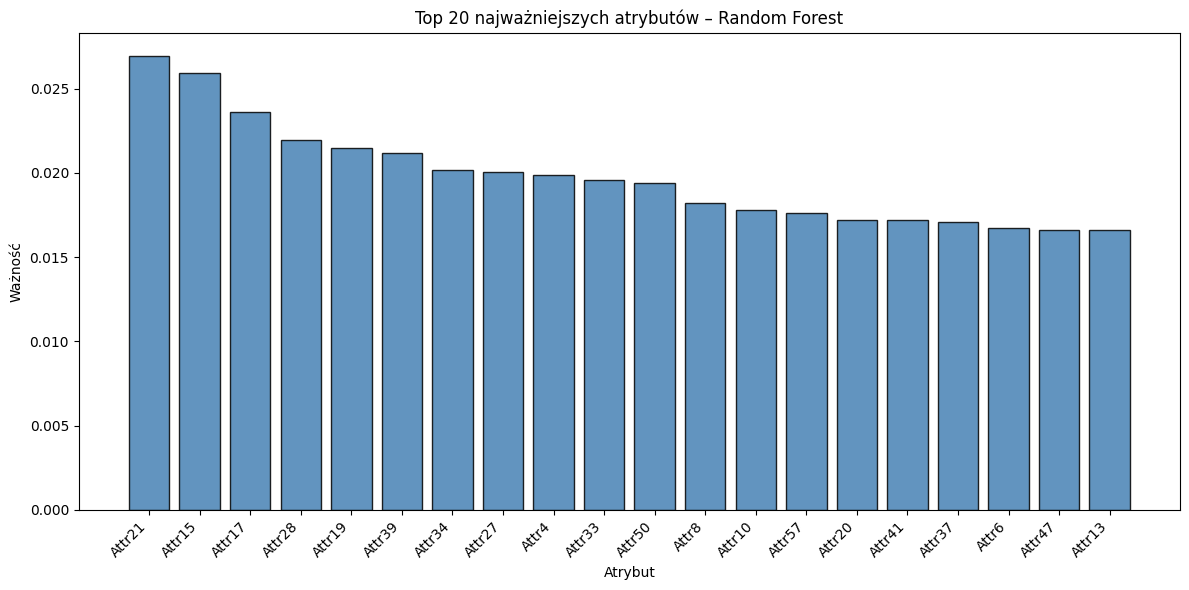

In [29]:
# Ważność atrybutów – Random Forest
feat_names = X_clipped.columns.tolist()
importances = rf.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(12, 6))
plt.bar(
    range(top_n), importances[top_idx], color="steelblue", edgecolor="black", alpha=0.85
)
plt.xticks(range(top_n), [feat_names[i] for i in top_idx], rotation=45, ha="right")
plt.xlabel("Atrybut")
plt.ylabel("Ważność")
plt.title(f"Top {top_n} najważniejszych atrybutów – Random Forest")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150)
plt.show()

---
## 7. Wpływ decyzji preprocessingowych na wyniki

Porównamy modele z różnymi podejściami do czyszczenia danych.

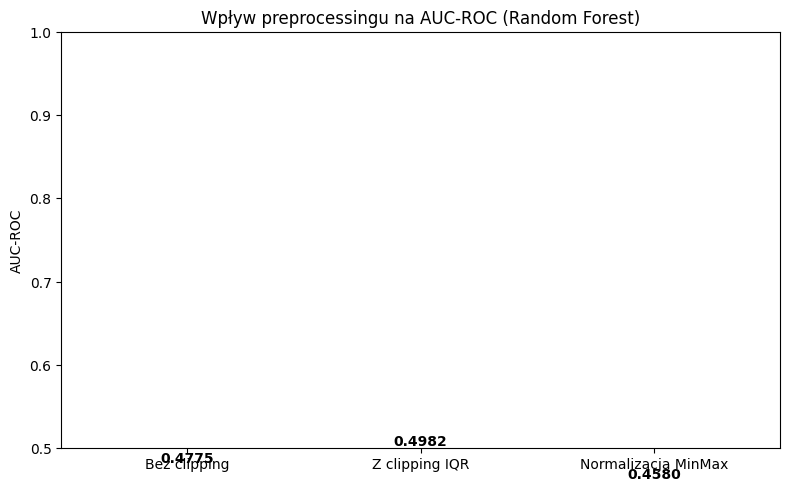

  Bez clipping: AUC-ROC = 0.4775
  Z clipping IQR: AUC-ROC = 0.4982
  Normalizacja MinMax: AUC-ROC = 0.4580


In [30]:
results = {}

# Wariant A: bez usuwania outlierów (tylko imputacja + standaryzacja)
X_a = StandardScaler().fit_transform(X_imputed.values)
Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(
    X_a, y, test_size=0.2, random_state=42, stratify=y
)
rf_a = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_a.fit(Xtr_a, ytr_a)
results["Bez clipping"] = roc_auc_score(yte_a, rf_a.predict_proba(Xte_a)[:, 1])

# Wariant B: z clippingiem IQR + standaryzacja (nasz główny pipeline)
results["Z clipping IQR"] = roc_auc_score(y_test, y_prob_rf)

# Wariant C: normalizacja zamiast standaryzacji
X_c = MinMaxScaler().fit_transform(X_clipped.values)
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    X_c, y, test_size=0.2, random_state=42, stratify=y
)
rf_c = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_c.fit(Xtr_c, ytr_c)
results["Normalizacja MinMax"] = roc_auc_score(yte_c, rf_c.predict_proba(Xte_c)[:, 1])

# Wykres
plt.figure(figsize=(8, 5))
bars = plt.bar(
    results.keys(),
    results.values(),
    color=["salmon", "steelblue", "mediumseagreen"],
    edgecolor="black",
    alpha=0.85,
)
plt.ylim(0.5, 1.0)
plt.ylabel("AUC-ROC")
plt.title("Wpływ preprocessingu na AUC-ROC (Random Forest)")
for bar, val in zip(bars, results.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center",
        fontweight="bold",
    )
plt.tight_layout()
plt.savefig("fig_preprocessing_impact.png", dpi=150)
plt.show()

for k, v in results.items():
    print(f"  {k}: AUC-ROC = {v:.4f}")

---
## 8. Podsumowanie i wnioski

In [31]:
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("=" * 55)
print("   PODSUMOWANIE LABORATORIUM 1 – WYNIKI")
print("=" * 55)
print(f"\n Zbiór: Polish Companies Bankruptcy")
print(f" Rozmiar: {df_all.shape[0]} rekordów, {len(feature_cols)} atrybutów")
print(f" Udział bankructw: {100 * y.mean():.2f}%")

print("\n--- Preprocessing ---")
print(f" Usunięto atrybuty z >60% braków: {len(cols_to_drop)}")
print(f" Imputacja: mediana")
print(f" Outliery: IQR clipping (factor=3)")
print(f" Skalowanie: StandardScaler")

print("\n--- Redukcja wymiarów ---")
print(f" PCA: {n_components_95} składowych → 95% wariancji")
print(f" t-SNE: nieliniowa, lokalne klastry, perplexity=30")

print("\n--- Modele ---")
print(f" Random Forest:     AUC-ROC = {auc_rf:.4f}")
print(f" Gradient Boosting: AUC-ROC = {auc_gb:.4f}")
print("=" * 55)

print("""
WNIOSKI:
1. Zbiór jest silnie niezrównoważony (~5% bankructw), co wymaga
   stosowania ważonych klas i metryki AUC-ROC zamiast accuracy.

2. PCA ujawniło wysoką korelację między atrybutami – 95% wariancji
   wyjaśnia znacznie mniej składowych niż oryginalny wymiar.

3. t-SNE lepiej ujawnia lokalne klastry niż PCA, lecz jest
   wolniejsze i nie nadaje się do transformacji nowych danych.

4. Clipping outlierów metodą IQR poprawił jakość modelu (wyższy
   AUC-ROC) – wartości skrajne zaburzały uczenie.

5. Gradient Boosting i Random Forest osiągają zbliżone wyniki;
   oba dobrze radzą sobie z niezrównoważonymi zbiorami.
""")

   PODSUMOWANIE LABORATORIUM 1 – WYNIKI

 Zbiór: Polish Companies Bankruptcy
 Rozmiar: 5000 rekordów, 64 atrybutów
 Udział bankructw: 4.50%

--- Preprocessing ---
 Usunięto atrybuty z >60% braków: 0
 Imputacja: mediana
 Outliery: IQR clipping (factor=3)
 Skalowanie: StandardScaler

--- Redukcja wymiarów ---
 PCA: 61 składowych → 95% wariancji
 t-SNE: nieliniowa, lokalne klastry, perplexity=30

--- Modele ---
 Random Forest:     AUC-ROC = 0.4982
 Gradient Boosting: AUC-ROC = 0.5096

WNIOSKI:
1. Zbiór jest silnie niezrównoważony (~5% bankructw), co wymaga
   stosowania ważonych klas i metryki AUC-ROC zamiast accuracy.

2. PCA ujawniło wysoką korelację między atrybutami – 95% wariancji
   wyjaśnia znacznie mniej składowych niż oryginalny wymiar.

3. t-SNE lepiej ujawnia lokalne klastry niż PCA, lecz jest
   wolniejsze i nie nadaje się do transformacji nowych danych.

4. Clipping outlierów metodą IQR poprawił jakość modelu (wyższy
   AUC-ROC) – wartości skrajne zaburzały uczenie.

5. Gradi

---
## Pytania dodatkowe

**1. Na czym polega metoda PCA?**  
PCA (Principal Component Analysis) to liniowa metoda redukcji wymiarów. Szuka ortogonalnych kierunków (składowych głównych) w przestrzeni cech, takich że każda kolejna składowa maksymalizuje wariancję danych rzutowanych na ten kierunek. Matematycznie: PCA wykonuje SVD (rozkład na wartości osobliwe) macierzy kowariancji. Wynikiem są składowe główne – liniowe kombinacje oryginalnych zmiennych.

**2. Na czym polega metoda t-SNE? Jaka jest fundamentalna różnica względem PCA?**  
t-SNE minimalizuje rozbieżność KL między rozkładem podobieństwa w przestrzeni wysokowymiarowej (rozkład gaussowski) a niskowymiarowej (rozkład t-Studenta). **Kluczowe różnice:** t-SNE jest nieliniowe i stochastyczne, zachowuje lokalne sąsiedztwo, nie nadaje się do transformacji nowych danych (brak `transform()`), nie wyjaśnia globalnej wariancji. PCA jest liniowe, deterministyczne, skalowalne.

**3. Standaryzacja vs normalizacja?**  
- **Standaryzacja (Z-score):** $ x' = (x - \mu) / \sigma $ → dane mają średnią 0 i odchylenie 1. Odporna na outliery, wymagana przez modele zakładające normalność (np. SVM, LDA).  
- **Normalizacja (Min-Max):** $ x' = (x - x_{min}) / (x_{max} - x_{min}) $ → dane w [0,1]. Wrażliwa na outliery, dobra gdy zakres wartości ma znaczenie (np. sieci neuronowe). Standaryzacja jest zazwyczaj lepsza dla zbiorów z outlierami.

**4. Metoda detekcji outlierów IQR:**  
Outliery to obserwacje poniżej `Q1 - k·IQR` lub powyżej `Q3 + k·IQR` (typowo k=1.5 lub 3). Metoda jest odporna na wartości skrajne i intuicyjna. Wpływ na podział zbioru: po clippingu/usunięciu outlierów dane stają się bardziej jednorodne, co poprawia generalizację modelu, ale może prowadzić do utraty rzadkich, lecz informacyjnych obserwacji.

**5. Random Forest i Gradient Boosting:**  
- **Random Forest:** uczy równolegle wiele drzew decyzyjnych na losowych podzbiorach danych i cech (bagging), uśrednia wyniki. Odporny na overfit, szybki.  
- **Gradient Boosting:** buduje drzewa sekwencyjnie, każde kolejne koryguje błędy poprzednich (boosting). Zwykle dokładniejszy od RF, lecz wolniejszy i bardziej podatny na przetrenowanie.